In [2]:
import pandas as pd
Customers=pd.read_excel("customers(clean).xlsx")
Products=pd.read_excel("products(clean).xlsx")
Orders=pd.read_excel("orders(clean).xlsx")

In [3]:
Customers.head()

,customer_id,signup_date,customer_age,customer_gender,state
0,CUST00544,2024-03-26,21,Other,MA
1,CUST00954,2022-01-27,56,Female,CA
2,CUST02898,2023-07-30,70,Other,WA
3,CUST02697,2022-01-27,23,Male,OH
4,CUST02413,2022-05-08,62,Male,FL


In [4]:
Products.head()

,product_id,product_name,product_category,unit_price
0,PROD0001,Bed Frame,Furniture,335.27
1,PROD0002,Puzzle,Toys,27.68
2,PROD0003,Office Chair,Furniture,47.15
3,PROD0004,Bookshelf,Furniture,141.11
4,PROD0005,Organic Coffee,Grocery,221.32


In [5]:
Orders.head()

,order_id,customer_id,product_id,order_date,quantity,discount_pct,total_amount,payment_method,shipping_city,shipping_state,delivery_days,marketing_channel,is_returning_customer,review_rating,return_flag
0,ORD000001,CUST00544,PROD0001,2024-12-23,4,0,1341.08,Apple Pay,MACity3,MA,6,Social Media,1,2,0
1,ORD000002,CUST00954,PROD0002,2023-05-02,5,25,103.80,Gift Card,CACity3,CA,5,Direct,1,2,0
2,ORD000003,CUST02898,PROD0003,2024-01-04,5,0,235.75,Credit Card,WACity3,WA,9,Organic Search,1,4,0
3,ORD000004,CUST02697,PROD0004,2023-05-21,1,5,134.05,PayPal,OHCity1,OH,14,Social Media,1,5,0
4,ORD000005,CUST02413,PROD0005,2022-05-31,3,20,531.17,Credit Card,FLCity1,FL,14,Organic Search,0,4,0


In [ ]:
Descriptive statistics

In [6]:
Orders[['quantity', 'discount_pct', 'total_amount',
        'delivery_days', 'review_rating']].describe()

,quantity,discount_pct,total_amount,delivery_days,review_rating
count,15050.000000,15050.000000,15050.000000,15050.000000,15050.000000
mean,3.004319,9.316279,680.077962,7.438870,3.670698
std,1.415639,9.226387,546.312894,3.995281,1.329295
min,1.000000,0.000000,5.070000,1.000000,1.000000
25%,2.000000,0.000000,246.045000,4.000000,3.000000
50%,3.000000,5.000000,518.970000,7.000000,4.000000
75%,4.000000,20.000000,1003.585000,11.000000,5.000000
max,5.000000,25.000000,2499.300000,14.000000,5.000000


In [7]:
# Mean vs median
Orders['total_amount'].median()

518.97

In [10]:
# Correlation
corr = Orders[
    ['quantity', 'discount_pct', 'total_amount',
     'delivery_days', 'review_rating']
].corr()

corr

,quantity,discount_pct,total_amount,delivery_days,review_rating
quantity,1.000000,-0.000257,0.587336,0.000006,-0.004788
discount_pct,-0.000257,1.000000,-0.124635,-0.005929,-0.003134
total_amount,0.587336,-0.124635,1.000000,-0.006002,-0.009534
delivery_days,0.000006,-0.005929,-0.006002,1.000000,0.002966
review_rating,-0.004788,-0.003134,-0.009534,0.002966,1.000000


AttributeError: module 'matplotlib' has no attribute 'show'

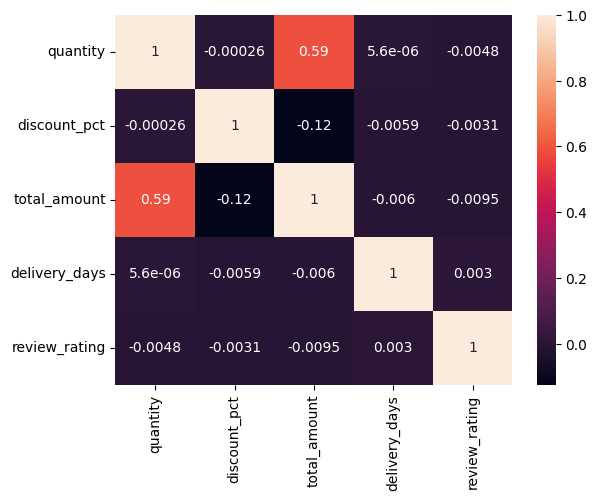

In [12]:
import seaborn as sns
sns.heatmap(corr, annot=True)
plt.show()

In [ ]:
Time Series Analysis 📈

In [13]:
# monthly revenue
monthly_revenue = (
    Orders
    .set_index('order_date')
    .resample('ME')['total_amount']
    .sum()
)

monthly_revenue

order_date
2022-01-31      5815.62
2022-02-28     25729.02
2022-03-31     45799.90
2022-04-30     79241.10
2022-05-31     92830.40
2022-06-30    118312.68
2022-07-31    133909.03
2022-08-31    167843.98
2022-09-30    170420.12
2022-10-31    190776.22
2022-11-30    221711.64
2022-12-31    237069.34
2023-01-31    274315.43
2023-02-28    267199.28
2023-03-31    305684.11
2023-04-30    310029.72
2023-05-31    319146.77
2023-06-30    345633.82
2023-07-31    384364.64
2023-08-31    392093.61
2023-09-30    325871.61
2023-10-31    354224.16
2023-11-30    339690.30
2023-12-31    324749.25
2024-01-31    392149.74
2024-02-29    315988.94
2024-03-31    350969.85
2024-04-30    354525.93
2024-05-31    300390.24
2024-06-30    370976.35
2024-07-31    370023.13
2024-08-31    322202.84
2024-09-30    304026.93
2024-10-31    226513.67
2024-11-30    802973.15
2024-12-31    691970.81
Freq: ME, Name: total_amount, dtype: float64

AttributeError: module 'matplotlib' has no attribute 'title'

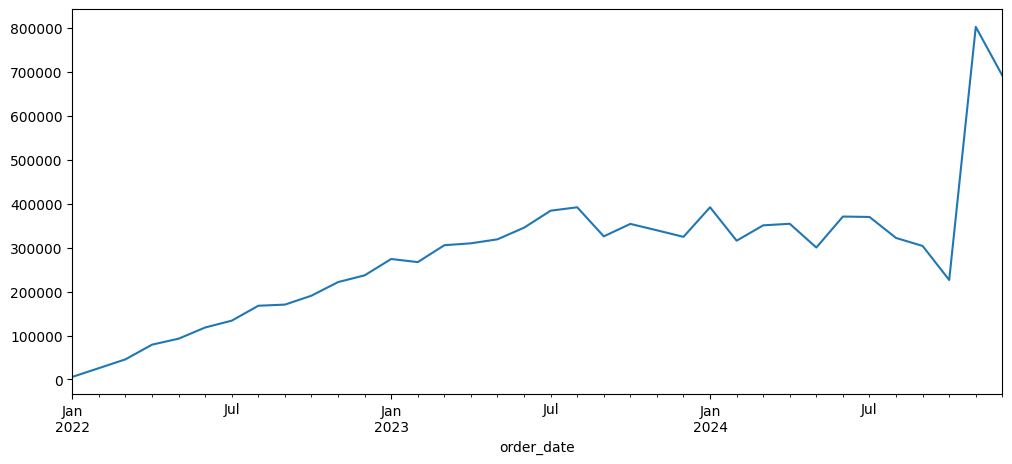

In [15]:
import matplotlib as plt
monthly_revenue.plot(kind='line', figsize=(12,5))

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

In [4]:
monthly_orders = (
    Orders
    .set_index('order_date')
    .resample('ME')['order_id']
    .nunique()
)

In [6]:
#Seasonal Analysis
Orders['month_name'] = Orders['order_date'].dt.month_name()
Orders['month_number'] = Orders['order_date'].dt.month

In [ ]:
High-sales months
Low-sales months
Seasonal demand

In [7]:
monthly_pattern = (
    Orders.groupby(['month_number', 'month_name'])['total_amount']
    .sum()
    .sort_index()
)

monthly_pattern

month_number  month_name
1             January        672280.79
2             February       608917.24
3             March          702453.86
4             April          743796.75
5             May            712367.41
6             June           834922.85
7             July           888296.80
8             August         882140.43
9             September      800318.66
10            October        771514.05
11            November      1364375.09
12            December      1253789.40
Name: total_amount, dtype: float64

In [ ]:
# Weekly sales

In [ ]:
weekly_sales = (
    Orders
    .set_index('order_date')
    .resample('W')['total_amount']
    .sum()
)

In [ ]:
Time Series + Marketing

In [10]:
#monthly revenue for each marketing channel (email,instagram,google....)
channel_monthly = (
    Orders
    .set_index('order_date')
    .groupby('marketing_channel')['total_amount']
    .resample('ME')
    .sum()
)